In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [25]:
class CricketState(TypedDict):
    runs:int
    balls:int
    fours:int
    sixes:int
    strikeRate:float
    boundaryPercentage:float
    ballsPerBoundary:float
    

In [30]:
def calculate_sr(state:CricketState)->CricketState:
    runs = state['runs']
    balls = state['balls']
    sr=(runs/balls)*100 if balls>0 else 0
    return {'strikeRate': sr}

def calculate_bp(state:CricketState)->CricketState:
    runs = state['runs']
    fours = state['fours']
    sixes = state['sixes']
    boundaryPercentage=((fours*4)+(sixes*6))/runs*100 if runs>0 else 0
    return {'boundaryPercentage': boundaryPercentage}

def calculate_bpb(state:CricketState)->CricketState:
    balls = state['balls']
    fours = state['fours']
    sixes = state['sixes']
    ballsPerBoundary=balls/(fours+sixes) if (fours+sixes)>0 else 0
    return {'ballsPerBoundary': ballsPerBoundary}

def summary(state:CricketState)->CricketState:
    print(f"Runs: {state['runs']}, Balls: {state['balls']}, Fours: {state['fours']}, Sixes: {state['sixes']}")
    print(f"Strike Rate: {state['strikeRate']:.2f}%, Boundary Percentage: {state['boundaryPercentage']:.2f}%, Balls per Boundary: {state['ballsPerBoundary']:.2f}")
    return state

In [31]:
graph =StateGraph(CricketState)

graph.add_node('calculate_sr',calculate_sr)
graph.add_node('calculate_bp',calculate_bp)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('summary',summary)

graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calculate_bp')
graph.add_edge(START,'calculate_bpb')
graph.add_edge('calculate_sr','summary')
graph.add_edge('calculate_bp','summary')
graph.add_edge('calculate_bpb','summary')
graph.add_edge('summary',END)

workflow=graph.compile()



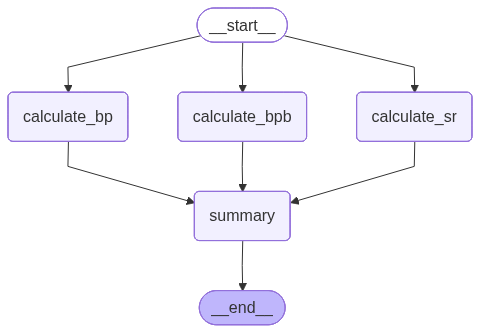

In [32]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())


In [34]:
initial_state={'runs': 120, 'balls': 100, 'fours': 10, 'sixes': 5}
final_state = workflow.invoke(initial_state)
print(final_state)

Runs: 120, Balls: 100, Fours: 10, Sixes: 5
Strike Rate: 120.00%, Boundary Percentage: 58.33%, Balls per Boundary: 6.67
{'runs': 120, 'balls': 100, 'fours': 10, 'sixes': 5, 'strikeRate': 120.0, 'boundaryPercentage': 58.333333333333336, 'ballsPerBoundary': 6.666666666666667}
